# Experiment: OCR Results Comparison Plots

Objective:
- Use `full_results.csv` to visualize how train/test split, window size, and method choice affect OCR performance.
- Focus on repeat-averaged test metrics so comparisons are stable across runs.


In [1]:
from __future__ import annotations

import os
from pathlib import Path

os.environ.setdefault('MPLCONFIGDIR', str(Path.cwd() / 'tmp' / 'mplconfig'))

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', lambda value: f'{value:.4f}')

DATA_PATH = Path.cwd() / 'outputs' / 'full_results.csv'
DATA_PATH


Matplotlib is building the font cache; this may take a moment.


PosixPath('/Users/camellee/OCR-comparison/outputs/full_results.csv')

## Plan

- Aggregate repeated runs by configuration before plotting.
- Use test accuracy as the primary comparison metric, with a compact summary table for reference.
- Produce one figure each for train/test split, window size, and `auto_context` vs `fixed_point`.


In [2]:
df = pd.read_csv(DATA_PATH)

numeric_columns = [
    'train_word_error', 'test_word_error', 'train_char_error', 'test_char_error',
    'train_time', 'test_time', 'repeat_index', 'window_radius', 'window_size',
    'n_train', 'n_test', 'train_word_acc', 'test_word_acc', 'train_char_acc', 'test_char_acc',
]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column])

df['split_label'] = (
    df['n_train'].astype(int).astype(str)
    + ' train / '
    + df['n_test'].astype(int).astype(str)
    + ' test'
)
df['train_fraction'] = df['n_train'] / (df['n_train'] + df['n_test'])

summary = (
    df.groupby(['method', 'n_train', 'n_test', 'window_size'], as_index=False)
      .agg(
          repeats=('repeat_index', 'count'),
          test_word_acc_mean=('test_word_acc', 'mean'),
          test_word_acc_std=('test_word_acc', 'std'),
          test_char_acc_mean=('test_char_acc', 'mean'),
          test_char_acc_std=('test_char_acc', 'std'),
          test_word_error_mean=('test_word_error', 'mean'),
          test_char_error_mean=('test_char_error', 'mean'),
      )
      .sort_values(['method', 'n_train', 'window_size'])
)
summary['split_label'] = (
    summary['n_train'].astype(int).astype(str)
    + ' train / '
    + summary['n_test'].astype(int).astype(str)
    + ' test'
)

summary.head(12)


,method,n_train,n_test,window_size,repeats,test_word_acc_mean,test_word_acc_std,test_char_acc_mean,test_char_acc_std,test_word_error_mean,test_char_error_mean,split_label
0,auto_context,1000,4000,1,3,0.3685,0.0053,0.8132,0.0027,0.6315,0.1868,1000 train / 4000 test
1,auto_context,1000,4000,3,3,0.3003,0.0075,0.7717,0.0027,0.6997,0.2283,1000 train / 4000 test
2,auto_context,1000,4000,5,3,0.3481,0.0064,0.7911,0.0024,0.6519,0.2089,1000 train / 4000 test
3,auto_context,2500,2500,1,3,0.4288,0.0167,0.8410,0.0017,0.5712,0.1590,2500 train / 2500 test
4,auto_context,2500,2500,3,3,0.3629,0.0044,0.8069,0.0030,0.6371,0.1931,2500 train / 2500 test
5,auto_context,2500,2500,5,3,0.4028,0.0056,0.8183,0.0019,0.5972,0.1817,2500 train / 2500 test
6,auto_context,4000,1000,1,3,0.4560,0.0104,0.8458,0.0073,0.5440,0.1542,4000 train / 1000 test
7,auto_context,4000,1000,3,3,0.4143,0.0115,0.8351,0.0029,0.5857,0.1649,4000 train / 1000 test
8,auto_context,4000,1000,5,3,0.4360,0.0090,0.8350,0.0022,0.5640,0.1650,4000 train / 1000 test
9,fixed_point,1000,4000,1,3,0.3733,0.0067,0.8085,0.0034,0.6267,0.1915,1000 train / 4000 test


## Effect of Train/Test Split

This view keeps the split on the x-axis and averages across window sizes so the impact of training set size is easy to compare across methods.


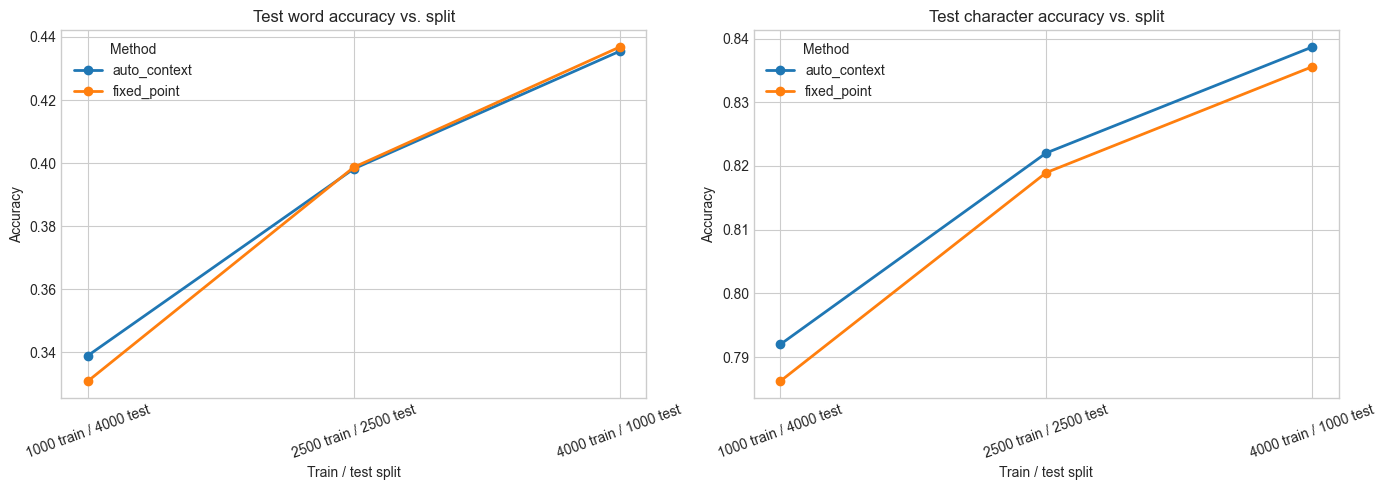

,method,n_train,n_test,split_label,test_word_acc_mean,test_char_acc_mean
0,auto_context,1000,4000,1000 train / 4000 test,0.3390,0.7920
3,fixed_point,1000,4000,1000 train / 4000 test,0.3309,0.7863
1,auto_context,2500,2500,2500 train / 2500 test,0.3982,0.8220
4,fixed_point,2500,2500,2500 train / 2500 test,0.3987,0.8190
2,auto_context,4000,1000,4000 train / 1000 test,0.4354,0.8387
5,fixed_point,4000,1000,4000 train / 1000 test,0.4368,0.8356


In [3]:
split_plot = (
    summary.groupby(['method', 'n_train', 'n_test', 'split_label'], as_index=False)
           .agg(
               test_word_acc_mean=('test_word_acc_mean', 'mean'),
               test_char_acc_mean=('test_char_acc_mean', 'mean'),
           )
           .sort_values('n_train')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for ax, metric, title in [
    (axes[0], 'test_word_acc_mean', 'Test word accuracy vs. split'),
    (axes[1], 'test_char_acc_mean', 'Test character accuracy vs. split'),
]:
    for method, group in split_plot.groupby('method'):
        group = group.sort_values('n_train')
        ax.plot(group['split_label'], group[metric], marker='o', linewidth=2, label=method)
    ax.set_title(title)
    ax.set_xlabel('Train / test split')
    ax.set_ylabel('Accuracy')
    ax.tick_params(axis='x', rotation=20)
    ax.legend(title='Method')

plt.tight_layout()
plt.show()

split_plot


## Effect of Window Size

This figure isolates window size and keeps separate lines for each train-set size, making it easier to see whether larger context windows help consistently.


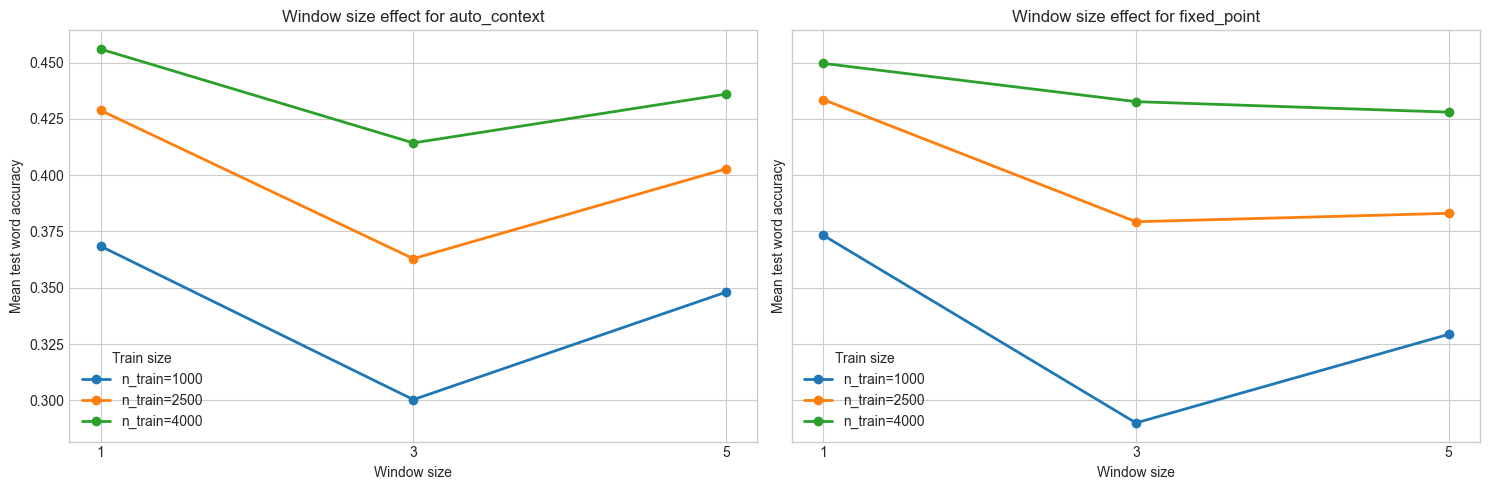

,method,window_size,n_train,test_word_acc_mean,test_char_acc_mean
0,auto_context,1,1000,0.3685,0.8132
3,auto_context,3,1000,0.3003,0.7717
6,auto_context,5,1000,0.3481,0.7911
1,auto_context,1,2500,0.4288,0.8410
4,auto_context,3,2500,0.3629,0.8069
7,auto_context,5,2500,0.4028,0.8183
2,auto_context,1,4000,0.4560,0.8458
5,auto_context,3,4000,0.4143,0.8351
8,auto_context,5,4000,0.4360,0.8350
9,fixed_point,1,1000,0.3733,0.8085


In [4]:
window_plot = (
    summary.groupby(['method', 'window_size', 'n_train'], as_index=False)
           .agg(
               test_word_acc_mean=('test_word_acc_mean', 'mean'),
               test_char_acc_mean=('test_char_acc_mean', 'mean'),
           )
           .sort_values(['method', 'n_train', 'window_size'])
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
methods = list(window_plot['method'].unique())
for ax, method in zip(axes, methods):
    method_frame = window_plot[window_plot['method'] == method]
    for n_train, group in method_frame.groupby('n_train'):
        group = group.sort_values('window_size')
        ax.plot(
            group['window_size'],
            group['test_word_acc_mean'],
            marker='o',
            linewidth=2,
            label=f'n_train={int(n_train)}',
        )
    ax.set_title(f'Window size effect for {method}')
    ax.set_xlabel('Window size')
    ax.set_ylabel('Mean test word accuracy')
    ax.set_xticks(sorted(window_plot['window_size'].unique()))
    ax.legend(title='Train size')

plt.tight_layout()
plt.show()

window_plot


## Auto-Context vs Fixed-Point

The first panel compares overall average performance by method. The second panel shows the per-configuration advantage of `auto_context` over `fixed_point` for test word accuracy.


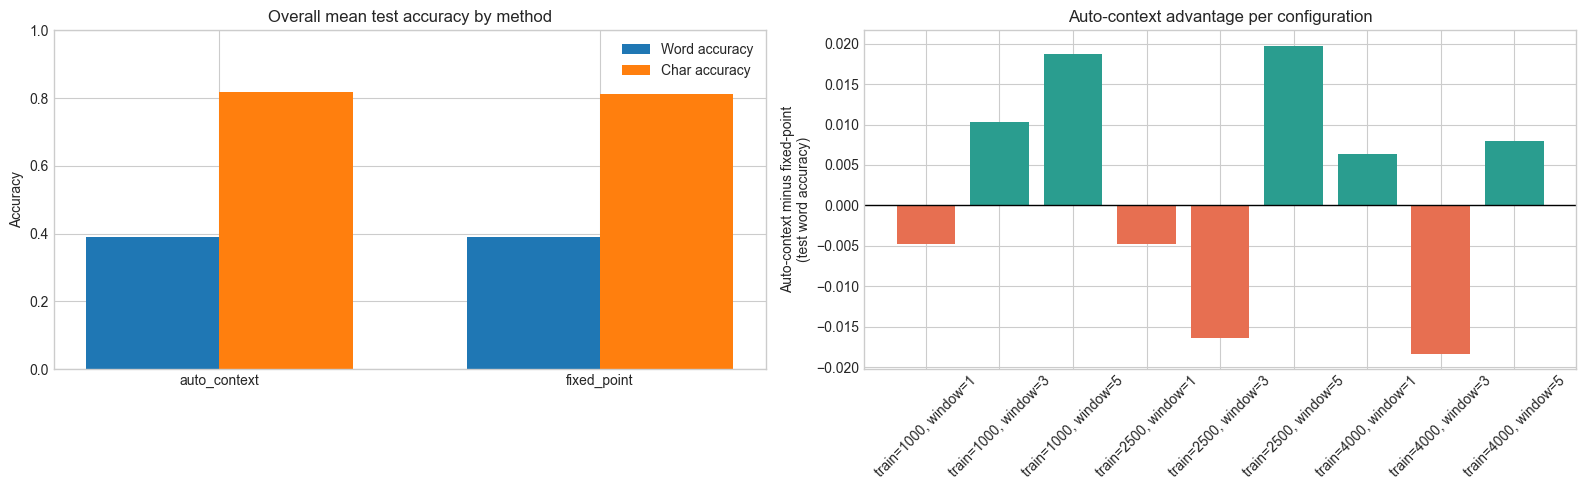

(         method  mean_test_word_acc  mean_test_char_acc  mean_test_word_error  \
 0  auto_context              0.3909              0.8176                0.6091   
 1   fixed_point              0.3888              0.8136                0.6112   
 
    mean_test_char_error  
 0                0.1824  
 1                0.1864  ,
 method  n_train  n_test  window_size  auto_minus_fixed
 0          1000    4000            1           -0.0048
 1          1000    4000            3            0.0103
 2          1000    4000            5            0.0187
 3          2500    2500            1           -0.0048
 4          2500    2500            3           -0.0164
 5          2500    2500            5            0.0197
 6          4000    1000            1            0.0063
 7          4000    1000            3           -0.0183
 8          4000    1000            5            0.0080)

In [5]:
method_summary = (
    summary.groupby('method', as_index=False)
           .agg(
               mean_test_word_acc=('test_word_acc_mean', 'mean'),
               mean_test_char_acc=('test_char_acc_mean', 'mean'),
               mean_test_word_error=('test_word_error_mean', 'mean'),
               mean_test_char_error=('test_char_error_mean', 'mean'),
           )
)

comparison = (
    summary.pivot_table(
        index=['n_train', 'n_test', 'window_size'],
        columns='method',
        values='test_word_acc_mean',
    )
    .reset_index()
)
comparison['auto_minus_fixed'] = comparison['auto_context'] - comparison['fixed_point']
comparison = comparison.sort_values(['n_train', 'window_size'])
comparison['config_label'] = comparison.apply(
    lambda row: f"train={int(row['n_train'])}, window={int(row['window_size'])}", axis=1
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

bar_positions = range(len(method_summary))
bar_width = 0.35
axes[0].bar(
    [x - bar_width / 2 for x in bar_positions],
    method_summary['mean_test_word_acc'],
    width=bar_width,
    label='Word accuracy',
)
axes[0].bar(
    [x + bar_width / 2 for x in bar_positions],
    method_summary['mean_test_char_acc'],
    width=bar_width,
    label='Char accuracy',
)
axes[0].set_xticks(list(bar_positions))
axes[0].set_xticklabels(method_summary['method'])
axes[0].set_ylim(0, 1)
axes[0].set_title('Overall mean test accuracy by method')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

colors = ['#2a9d8f' if value >= 0 else '#e76f51' for value in comparison['auto_minus_fixed']]
axes[1].bar(comparison['config_label'], comparison['auto_minus_fixed'], color=colors)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Auto-context advantage per configuration')
axes[1].set_ylabel('Auto-context minus fixed-point\n(test word accuracy)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

method_summary, comparison[['n_train', 'n_test', 'window_size', 'auto_minus_fixed']]


## Findings Template

After running the notebook, summarize:
- Which train/test split gives the strongest test accuracy.
- Whether a larger window is consistently beneficial.
- In which configurations `auto_context` beats `fixed_point`, and by how much.
